# Predicting House Prices in California with `LinearRegression()`

In this lab you will start inspect, analyze, visualize house price data from different districts in California, US. After having performed analysis, EDA and some feature engineering, you will build your own `LinearRegression()`  with `SkLearn`. 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
%matplotlib inline

# Part 1 - Inspection and Cleaning


#### Import and Inspect your data

Read the `housing.csv` file and make use of some methods to understand your data better. Below is an explanation of the features you are going to work with:

1. **longitude:**  geographical coordinate, east to west position of district
2. **latitude:**  geographical coordinate, north to south position of district
3. **housing_median_age:** the median age of houses in district
4. **total_rooms** Sum of all rooms in district
5. **total_bedrooms** Sum of all bedrooms in district
6. **population:** total population in district
7. **households:** total households in district
8. **median_income:** median household income in district 
9. **median_house_value:** median house value in district
10. **ocean_proximity:** District´s proximity to the ocean

In [2]:
df = pd.read_csv('C:\\Users\\felip\\jupyter_notebooks\\IronHack\\lab-ml-and-linear-regression-main\\data\\housing.csv')

In [3]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
df.ocean_proximity.unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

#### Histograms
Make histograms of all your numeric columns in order to get a good understanding of the distribution of your data points. What do you see?

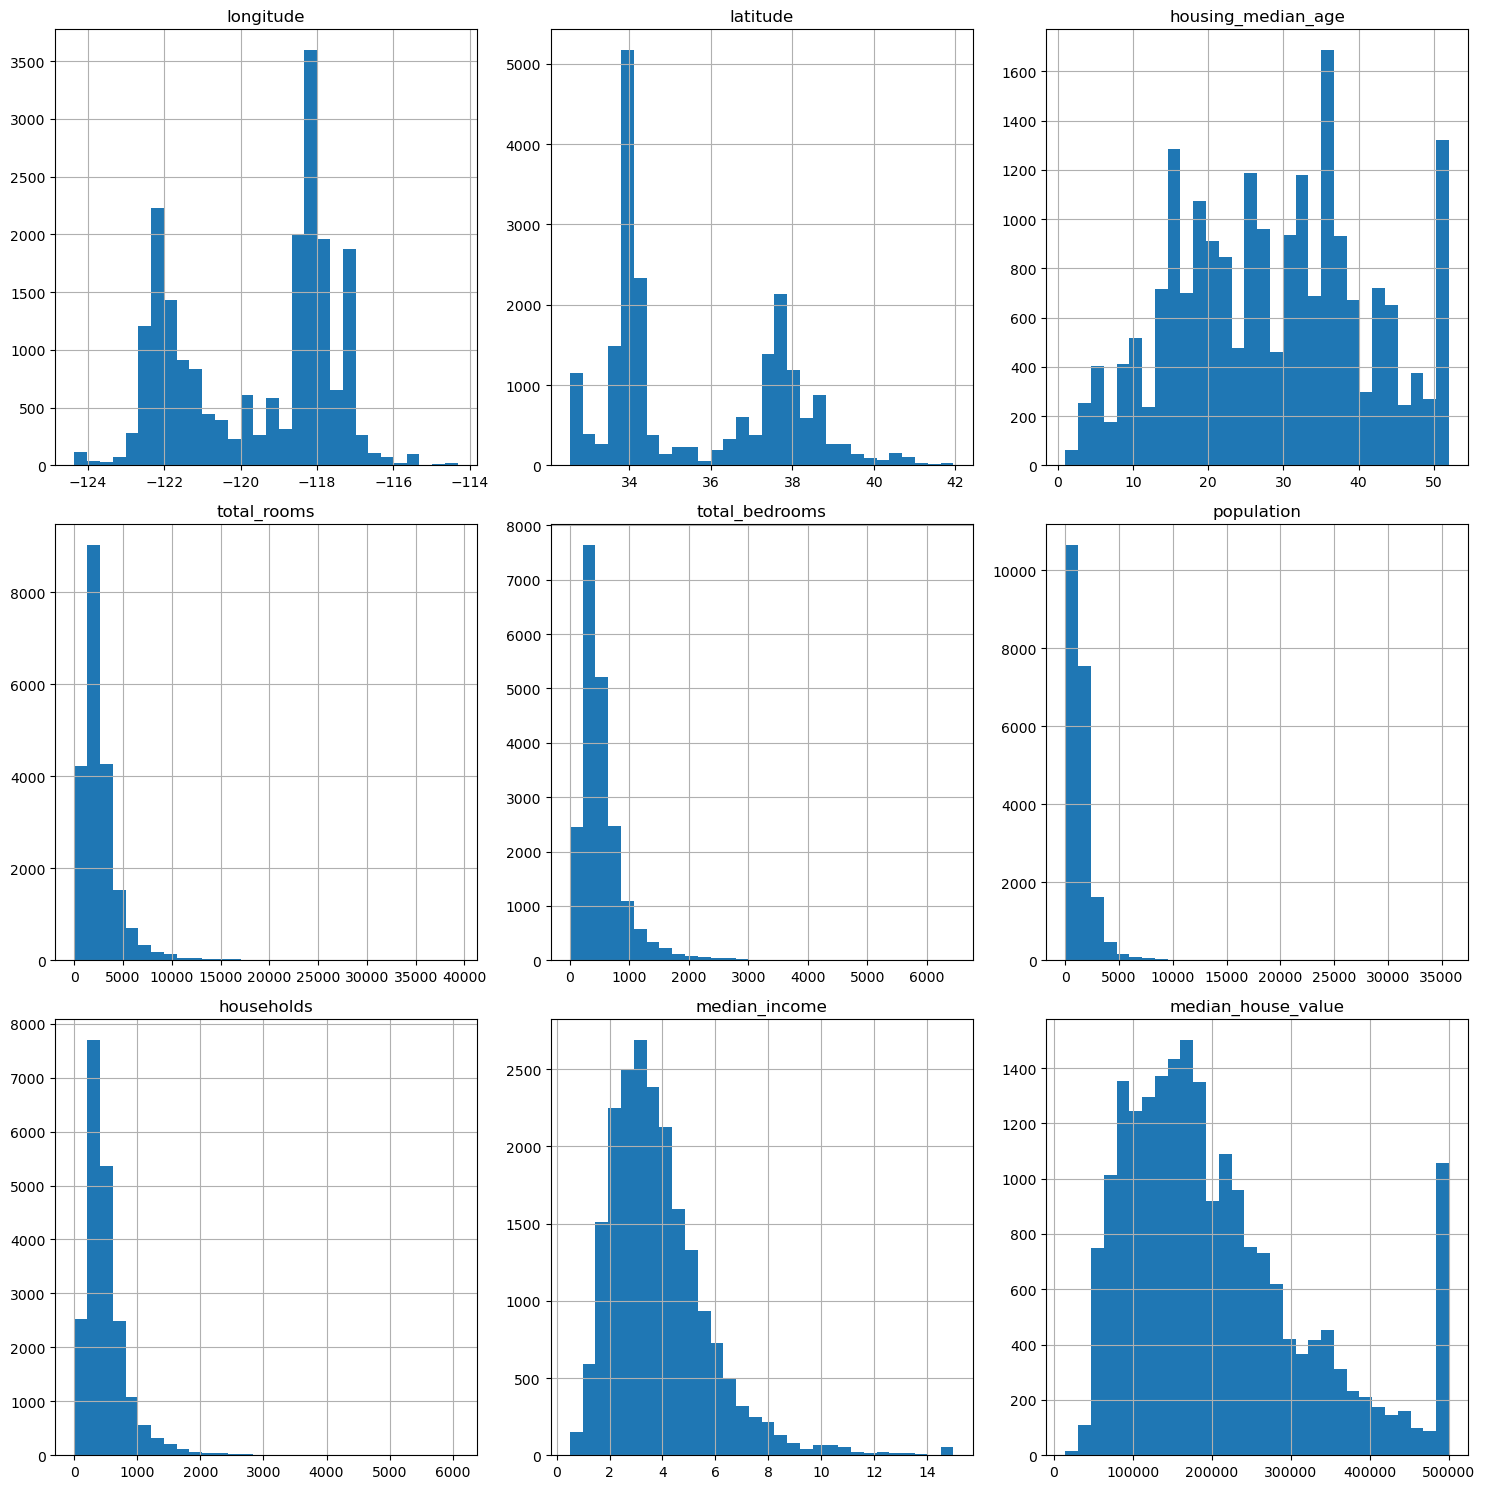

In [8]:
axes = df.iloc[:,:-1].hist(figsize=(15, 15), bins=30)
plt.tight_layout()
plt.show()

#### Let's create some features a tidy up our data

1. Locate your NaN values and make a decision on how to handle them. Drop, fill with mean, or something else, it is entirely up to you. 

In [9]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [10]:
print(df.total_bedrooms.min())
print(df.total_bedrooms.max())
print(df.total_bedrooms.mean())
print(df.total_bedrooms.median())

1.0
6445.0
537.8705525375618
435.0


In [11]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

2. Create three new columns by using simple arithmetic operations. Create one column with "rooms per household", one with "population per household",  and one with "bedrooms per room".

In [12]:
df['rooms_per_household'] = df['total_rooms']/df['households']

In [13]:
df["population_per_household"] = df['population']/df['households']

In [14]:
df["bedrooms_per_room"] = df['total_bedrooms']/df['total_rooms']

In [15]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'rooms_per_household',
       'population_per_household', 'bedrooms_per_room'],
      dtype='object')

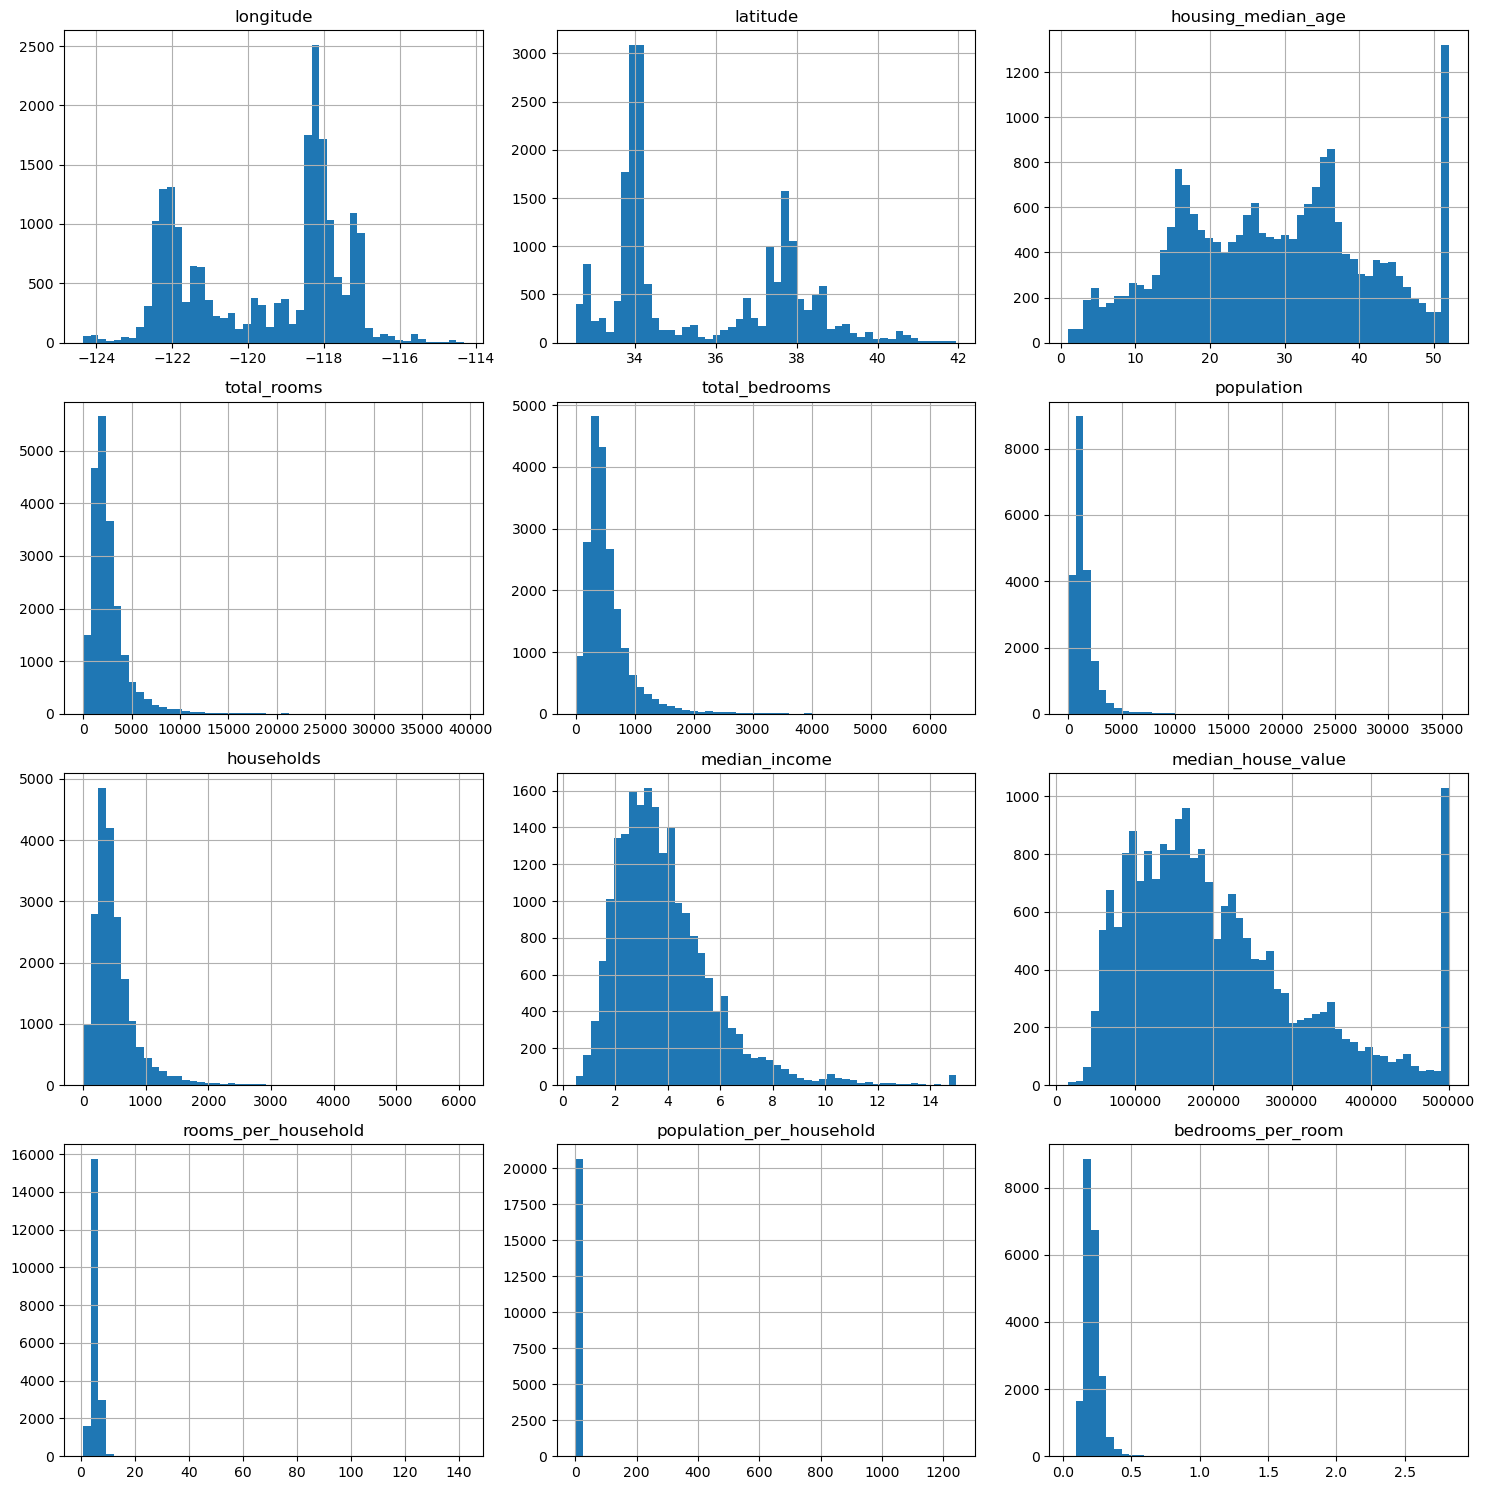

In [16]:
axes = df[['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'rooms_per_household',
       'population_per_household', 'bedrooms_per_room']].hist(figsize=(15, 15), bins=50)
plt.tight_layout()
plt.show()

3. If you check the largest and smallest values of your "rooms per houshold column" you will see two outliers and two values that are just wrong. Drop the four values by index.

In [17]:
df['rooms_per_household'].nlargest(5)

1914     141.909091
1979     132.533333
12447     62.422222
1913      61.812500
11862     59.875000
Name: rooms_per_household, dtype: float64

In [18]:
df['rooms_per_household'].nsmallest(5)

5916     0.846154
8219     0.888889
3126     1.000000
14818    1.130435
17820    1.130435
Name: rooms_per_household, dtype: float64

In [19]:
df = df.drop(index=[1914,1979,5916,8219])

# Part 2 - Exploratory Data Analysis



#### Let's find out what factors have an influence on our predicting variable

1. Let's check out the distribution of our "median house value". Visualize your results with 100 bins.

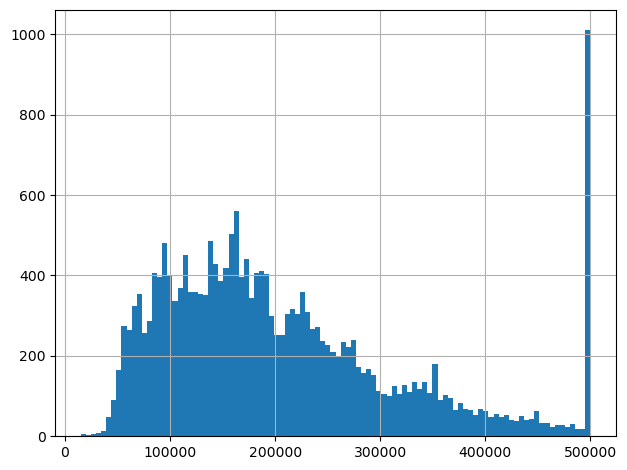

In [20]:
df.median_house_value.hist(bins=100)
plt.tight_layout()
plt.show()

2. Check out what variables correlates the most with "median house value"

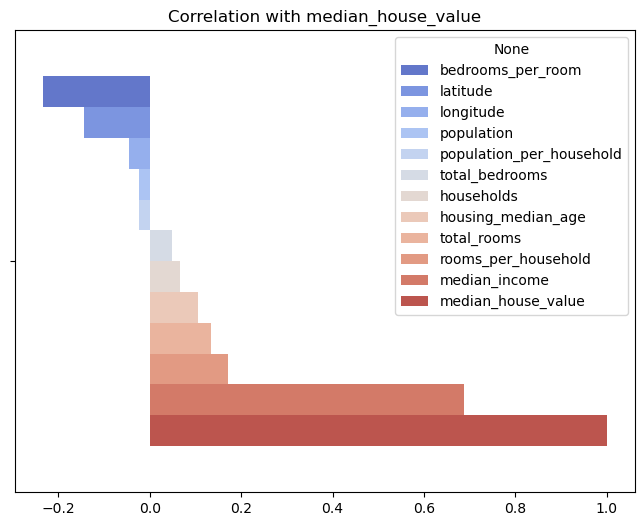

bedrooms_per_room          -0.233824
latitude                   -0.144413
longitude                  -0.045911
population                 -0.024598
population_per_household   -0.023743
total_bedrooms              0.049471
households                  0.065927
housing_median_age          0.105653
total_rooms                 0.134173
rooms_per_household         0.171586
median_income               0.688369
median_house_value          1.000000
Name: median_house_value, dtype: float64


In [21]:
corr = df.corr(numeric_only=True).median_house_value.sort_values()
plt.figure(figsize=(8, 6))
sns.barplot(
    x=corr.values,
    hue=corr.index,
    palette="coolwarm"
)
plt.title("Correlation with median_house_value")
plt.show()

print(corr)

3. Let's check out the distribution of the column that has the highest correlation to "median house value". Visualize your results with 100 bins.

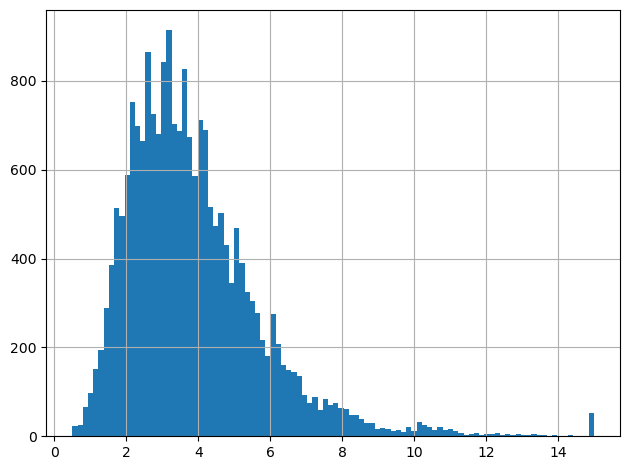

In [22]:
df.median_income.hist(bins=100)
plt.tight_layout()
plt.show()

4. Visualize the "median house value" and "median income" in a jointplot (kind="reg"). What do you see?

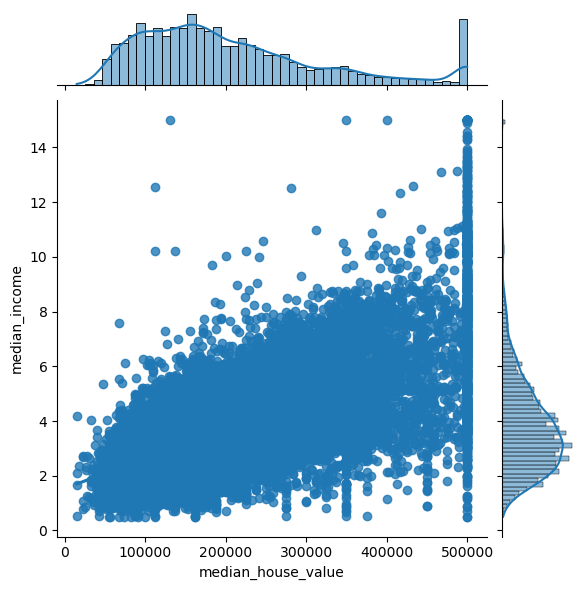

In [23]:
sns.jointplot(
    data=df,
    x="median_house_value",
    y="median_income",
    kind="reg"
)

5. Make the same visualization as in the above, but, cahnge the kind parameter to "kde". What extra information does this type of visualization convey, that the one in the above does not?

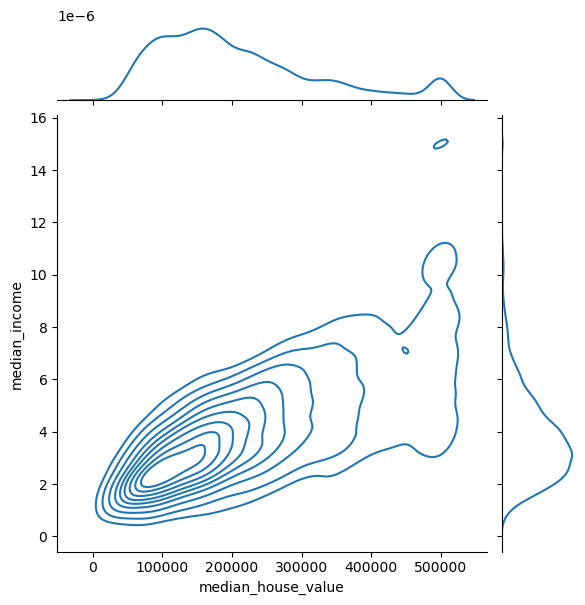

In [24]:
sns.jointplot(
    data=df,
    x="median_house_value",
    y="median_income",
    kind="kde"
)

#### Let's get schwifty with some EDA

1. Create a new categorical column from the "median income" with the following quartiles `[0, 0.25, 0.5, 0.75, 0.95, 1]` and label them like this `["Low", "Below_Average", "Above_Average", "High", "Very High"]` and name the column "income_cat"

In [25]:
q = df['median_income'].quantile([0, 0.25, 0.5, 0.75, 0.95, 1])

df['income_cat'] = pd.cut(df["median_income"],
                          bins=[-float("inf"), q[0.25], q[0.5], q[0.75], q[0.95], float("inf")], 
                          labels=["Low", "Below_Average", "Above_Average", "High", "Very High"]
                         )

df['income_cat']

0            Very High
1            Very High
2                 High
3                 High
4        Above_Average
             ...      
20635              Low
20636              Low
20637              Low
20638              Low
20639              Low
Name: income_cat, Length: 20636, dtype: category
Categories (5, object): ['Low' < 'Below_Average' < 'Above_Average' < 'High' < 'Very High']

2. Using the Seaborn library, plot the count of your new column and set the `hue` to "ocean_proximity". What interesting things can you see?

<Axes: xlabel='income_cat', ylabel='count'>

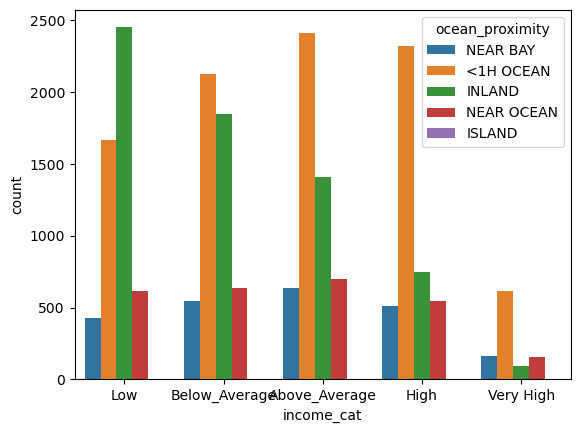

In [26]:
sns.countplot(df, x='income_cat', hue='ocean_proximity')

3. Create two barplots where you set "y="median_house_value" on both, and the x is first "income cat" and then "ocean_proximity". How does these two graphs complement what you saw in the graph in your previous question?

<Axes: xlabel='income_cat', ylabel='median_house_value'>

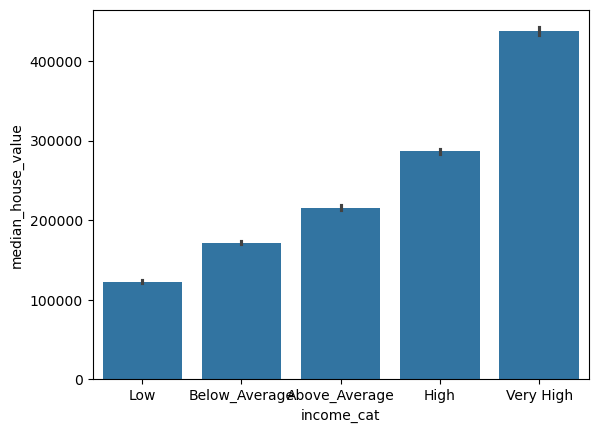

In [27]:
sns.barplot(df, x = 'income_cat', y = 'median_house_value' )

<Axes: xlabel='ocean_proximity', ylabel='median_house_value'>

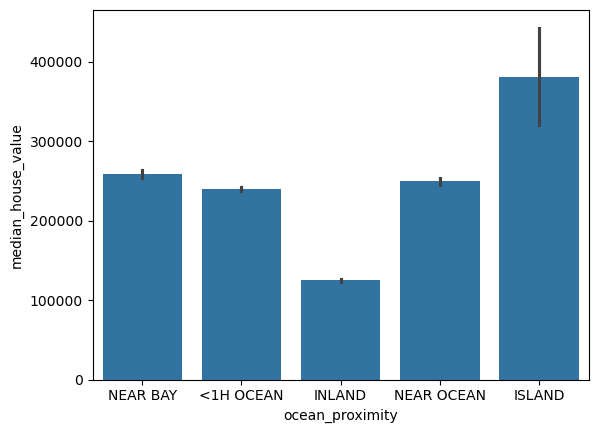

In [28]:
sns.barplot(df, x = 'ocean_proximity', y = 'median_house_value' )

In [29]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9135
INLAND        6549
NEAR OCEAN    2657
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

These two graphs show that even when ISLAND do not appear on the first graph, it has the greatest house values and INLAND the lesser value

4. Create a pivoted dataframe where you have the values of the "income cat" column as indices and the values of the "ocean_proximity" column as columns. Also drop the "ISLAND" column that you'll get.

In [30]:
pivoted_df = df.pivot_table(index='income_cat', columns='ocean_proximity')

pivoted_df

C:\Users\felip\AppData\Local\Temp\ipykernel_19564\1668531546.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivoted_df = df.pivot_table(index='income_cat', columns='ocean_proximity')


bedrooms_per_room                                           \
ocean_proximity         <1H OCEAN    INLAND    ISLAND  NEAR BAY NEAR OCEAN   
income_cat                                                                   
Low                      0.295463  0.235145  0.311045  0.273133   0.279534   
Below_Average            0.244241  0.201984  0.263797  0.236213   0.236423   
Above_Average            0.207617  0.182821       NaN  0.208630   0.203909   
High                     0.171327  0.157411       NaN  0.172509   0.174288   
Very High                0.140263  0.166900       NaN  0.139600   0.142725   

                 households                                             ...  \
ocean_proximity   <1H OCEAN      INLAND ISLAND    NEAR BAY  NEAR OCEAN  ...   
income_cat                                                              ...   
Low              493.127022  422.075133  331.0  432.638498  467.543974  ...   
Below_Average    560.371940  481.054683  263.0  514.233577  520.932390  ...   
Above_Average    515.657960  540.762243    NaN  505.103448  519.731812  ...   
High             514.970233  540.473262    NaN  514.756335  503.053016  ...   
Very High        456.500000  409.947917    NaN  403.036364  467.830189  ...   

                total_bedrooms                                              \
ocean_proximity      <1H OCEAN      INLAND  ISLAND    NEAR BAY  NEAR OCEAN   
income_cat                                                                   
Low                 528.321150  478.384238  521.00  464.267606  508.346906   
Below_Average       594.693032  542.681104  395.25  545.447080  562.036164   
Above_Average       543.582090  593.565649     NaN  530.418495  554.298146   
High                533.518982  582.516043     NaN  531.450292  531.723949   
Very High           472.354575  471.625000     NaN  413.157576  500.113208   

                 total_rooms                                                 
ocean_proximity    <1H OCEAN       INLAND  ISLAND     NEAR BAY   NEAR OCEAN  
income_cat                                                                   
Low              1829.877771  2080.808085  1675.0  1728.089202  1878.925081  
Below_Average    2440.060264  2692.620466  1549.5  2309.248175  2417.916667  
Above_Average    2638.907546  3269.575586     NaN  2535.642633  2728.503566  
High             3154.969370  3739.812834     NaN  3114.033138  3116.352834  
Very High        3427.316993  3406.281250     NaN  2990.587879  3513.610063  

[5 rows x 60 columns]

In [31]:
pivoted_df.info()

<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 5 entries, Low to Very High
Data columns (total 60 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   (bedrooms_per_room, <1H OCEAN)          5 non-null      float64
 1   (bedrooms_per_room, INLAND)             5 non-null      float64
 2   (bedrooms_per_room, ISLAND)             2 non-null      float64
 3   (bedrooms_per_room, NEAR BAY)           5 non-null      float64
 4   (bedrooms_per_room, NEAR OCEAN)         5 non-null      float64
 5   (households, <1H OCEAN)                 5 non-null      float64
 6   (households, INLAND)                    5 non-null      float64
 7   (households, ISLAND)                    2 non-null      float64
 8   (households, NEAR BAY)                  5 non-null      float64
 9   (households, NEAR OCEAN)                5 non-null      float64
 10  (housing_median_age, <1H OCEAN)         5 non-null

In [32]:
pivoted_df = pivoted_df.drop(columns=[('bedrooms_per_room', 'ISLAND'), 
                                      ('households', 'ISLAND'), 
                                      ('housing_median_age', 'ISLAND'),
                                      ('latitude', 'ISLAND'),
                                      ('longitude', 'ISLAND'),
                                      ('median_house_value', 'ISLAND'),
                                      ('median_income', 'ISLAND'),
                                      ('population', 'ISLAND'),
                                      ('population_per_household', 'ISLAND'),
                                      ('rooms_per_household', 'ISLAND'),
                                      ('total_bedrooms', 'ISLAND'),
                                      ('total_rooms', 'ISLAND')
                                     ])
pivoted_df

bedrooms_per_room                                 households  \
ocean_proximity         <1H OCEAN    INLAND  NEAR BAY NEAR OCEAN   <1H OCEAN   
income_cat                                                                     
Low                      0.295463  0.235145  0.273133   0.279534  493.127022   
Below_Average            0.244241  0.201984  0.236213   0.236423  560.371940   
Above_Average            0.207617  0.182821  0.208630   0.203909  515.657960   
High                     0.171327  0.157411  0.172509   0.174288  514.970233   
Very High                0.140263  0.166900  0.139600   0.142725  456.500000   

                                                    housing_median_age  \
ocean_proximity      INLAND    NEAR BAY  NEAR OCEAN          <1H OCEAN   
income_cat                                                               
Low              422.075133  432.638498  467.543974          33.343919   
Below_Average    481.054683  514.233577  520.932390          30.513653   
Above_Average    540.762243  505.103448  519.731812          29.521559   
High             540.473262  514.756335  503.053016          25.919758   
Very High        409.947917  403.036364  467.830189          25.651961   

                            ... rooms_per_household            total_bedrooms  \
ocean_proximity     INLAND  ...            NEAR BAY NEAR OCEAN      <1H OCEAN   
income_cat                  ...                                                 
Low              27.890568  ...            4.255262   4.097054     528.321150   
Below_Average    24.497022  ...            4.597335   4.735438     594.693032   
Above_Average    21.058197  ...            5.124375   5.321866     543.582090   
High             18.339572  ...            6.113124   6.190613     533.518982   
Very High        20.822917  ...            7.395394   7.499723     472.354575   

                                                     total_rooms               \
ocean_proximity      INLAND    NEAR BAY  NEAR OCEAN    <1H OCEAN       INLAND   
income_cat                                                                      
Low              478.384238  464.267606  508.346906  1829.877771  2080.808085   
Below_Average    542.681104  545.447080  562.036164  2440.060264  2692.620466   
Above_Average    593.565649  530.418495  554.298146  2638.907546  3269.575586   
High             582.516043  531.450292  531.723949  3154.969370  3739.812834   
Very High        471.625000  413.157576  500.113208  3427.316993  3406.281250   

                                           
ocean_proximity     NEAR BAY   NEAR OCEAN  
income_cat                                 
Low              1728.089202  1878.925081  
Below_Average    2309.248175  2417.916667  
Above_Average    2535.642633  2728.503566  
High             3114.033138  3116.352834  
Very High        2990.587879  3513.610063  

[5 rows x 48 columns]

5. Turn your pivoted dataframe into a heatmap. The heatmap should have annotations in integer format.

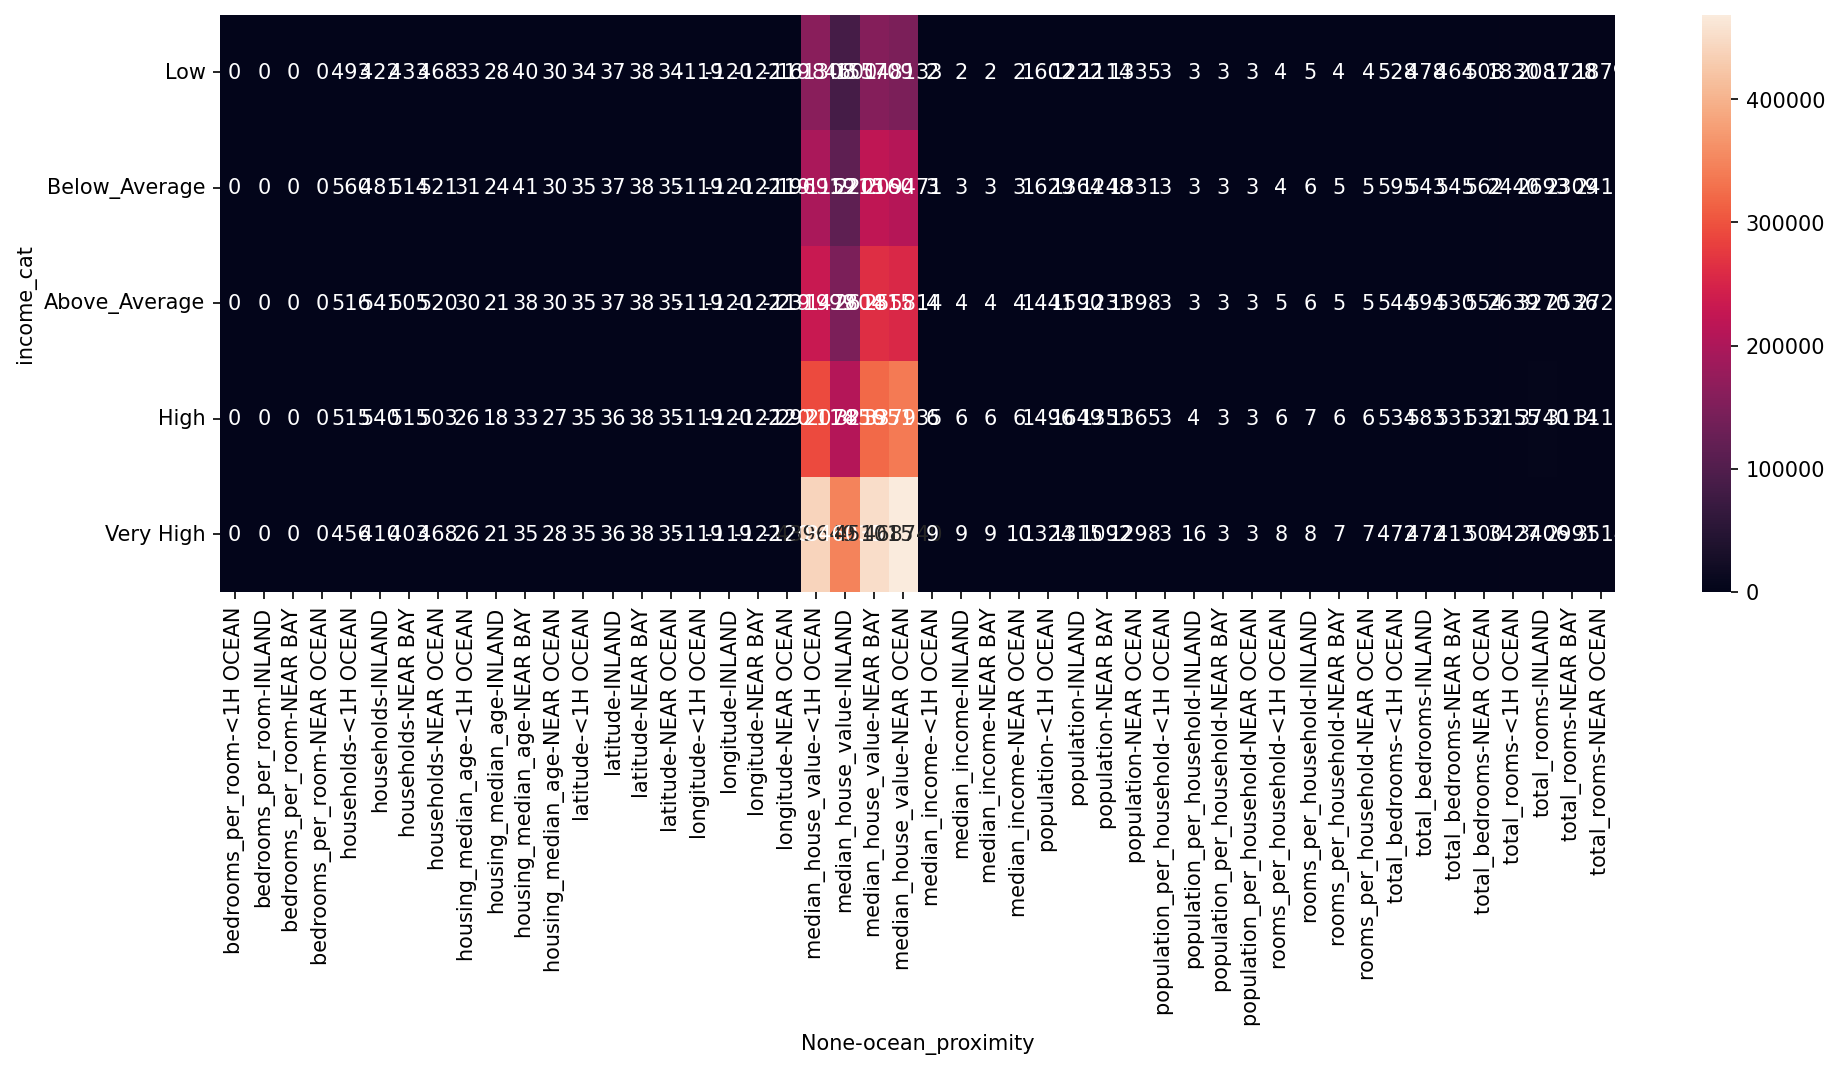

In [33]:
plt.figure(figsize=(15, 5), dpi=150)
sns.heatmap(pivoted_df.round(0).astype(int), annot=True, fmt='d')
plt.show()

# Part 3 - Preparing your Data



#### Splitting, Preparing and Engineering some Features

1. Let's drop the "income_cat" column as it has served its purpose already. We don't need for our model as we already have "median income".
Not dropping "incom cat" will lead to multicolinearity.

In [34]:
df = df.drop('income_cat', axis=1)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,population_per_household,bedrooms_per_room
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,2.555556,0.146591
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,2.109842,0.155797
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,2.802260,0.129516
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,2.547945,0.184458
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,2.181467,0.172096
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,5.045455,2.560606,0.224625
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,6.114035,3.122807,0.215208
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,5.205543,2.325635,0.215173
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,5.329513,2.123209,0.219892


2. Select your floating point columns and standardize your data by calculating the Z-score. You can apply the `stats.zscore()` method in a lambda function. Save your results to a variable called `z_scored`. 

In [35]:
import scipy.stats as stats

In [40]:
floats_cols = df.select_dtypes(include='float').columns
z_scored = (df[floats_cols]-df[floats_cols].mean())/df[floats_cols].std() # value - mean / std deviation
z_scored

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,population_per_household,bedrooms_per_room
0,-1.327669,1.052640,0.982200,-0.804938,-0.972594,-0.974687,-0.977308,2.344539,2.129802,0.744306,-0.049603,-1.033390
1,-1.322678,1.043276,-0.606859,2.045647,1.356940,0.861222,1.669771,2.332012,1.314279,0.390073,-0.092513,-0.891716
2,-1.332660,1.038594,1.856182,-0.535877,-0.827147,-0.821032,-0.843908,1.782517,1.258813,1.363513,-0.025852,-1.296169
3,-1.337650,1.038594,1.856182,-0.624342,-0.719850,-0.766281,-0.734049,0.932854,1.165215,0.190264,-0.050336,-0.450617
4,-1.337650,1.038594,1.856182,-0.462538,-0.612553,-0.760100,-0.629421,-0.012919,1.173014,0.410832,-0.085618,-0.640873
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-0.758716,1.801751,-0.289047,-0.445120,-0.388422,-0.512839,-0.443707,-1.216069,-1.115824,-0.176271,-0.049117,0.167534
20636,-0.818606,1.806433,-0.845217,-0.888820,-0.922522,-0.944662,-1.008696,-0.691576,-1.124490,0.331144,0.005009,0.022614
20637,-0.823597,1.778341,-0.924670,-0.175142,-0.123756,-0.369782,-0.174291,-1.142540,-0.992758,-0.100253,-0.071738,0.022075
20638,-0.873505,1.778341,-0.845217,-0.355739,-0.304969,-0.604679,-0.394009,-1.054537,-1.058624,-0.041386,-0.091226,0.094707


In [52]:
z_scored = df.select_dtypes(include="float").apply(
    lambda x: stats.zscore(x))
z_scored.drop(columns=['median_house_value'], inplace=True)

3. Turn the only categorical columns into dummies. Be vary of the dummy trap, to avoid multicolinearity.

In [46]:
# print(df.columns)
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,population_per_household,bedrooms_per_room,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,2.555556,0.146591,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,2.109842,0.155797,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,2.802260,0.129516,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,2.547945,0.184458,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,2.181467,0.172096,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,5.045455,2.560606,0.224625,True,False,False,False
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,6.114035,3.122807,0.215208,True,False,False,False
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,5.205543,2.325635,0.215173,True,False,False,False
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,5.329513,2.123209,0.219892,True,False,False,False


4. Save our predicting variable to `y`.

In [47]:
y = df['median_house_value']

5. Concatenate `z_scored` and `dummies` and drop the predicting variable. Save to the varible `X`.

In [53]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'rooms_per_household', 'population_per_household',
       'bedrooms_per_room', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')

In [57]:
dummies = df[['ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']]
X = pd.concat([z_scored, dummies], axis=1)
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,population_per_household,bedrooms_per_room,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.327701,1.052665,0.982224,-0.804958,-0.972617,-0.974710,-0.977332,2.344595,0.744324,-0.049604,-1.033415,False,False,True,False
1,-1.322710,1.043301,-0.606873,2.045696,1.356973,0.861243,1.669812,2.332068,0.390083,-0.092516,-0.891738,False,False,True,False
2,-1.332692,1.038619,1.856227,-0.535890,-0.827167,-0.821052,-0.843928,1.782561,1.363546,-0.025852,-1.296200,False,False,True,False
3,-1.337683,1.038619,1.856227,-0.624357,-0.719867,-0.766300,-0.734067,0.932876,0.190268,-0.050337,-0.450628,False,False,True,False
4,-1.337683,1.038619,1.856227,-0.462549,-0.612568,-0.760118,-0.629436,-0.012919,0.410842,-0.085620,-0.640889,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-0.758734,1.801795,-0.289054,-0.445131,-0.388431,-0.512852,-0.443718,-1.216099,-0.176275,-0.049118,0.167538,True,False,False,False
20636,-0.818626,1.806477,-0.845238,-0.888841,-0.922544,-0.944685,-1.008721,-0.691592,0.331152,0.005009,0.022615,True,False,False,False
20637,-0.823617,1.778385,-0.924693,-0.175146,-0.123759,-0.369791,-0.174295,-1.142568,-0.100255,-0.071740,0.022076,True,False,False,False
20638,-0.873526,1.778385,-0.845238,-0.355747,-0.304976,-0.604694,-0.394019,-1.054562,-0.041387,-0.091229,0.094709,True,False,False,False


# Part 4 - Machine Learning 




#### Train, Test, Split

1. Import `train_test_split` and split your data accordingly. Choose an appropriate test size.

In [56]:
from sklearn.model_selection import train_test_split

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=.5)

#### Building and Training our Model

2. Build, fit and train a `LinearRegression` model. 

In [79]:
from sklearn.linear_model import LinearRegression

rgsr = LinearRegression()
rgsr.fit(X_train,y_train)

y_pred = rgsr.predict(X_test)

3. In a scatterplot, visualize the y_train on your x-axis and your predictions on the y-axis. How does your training predictions look? 

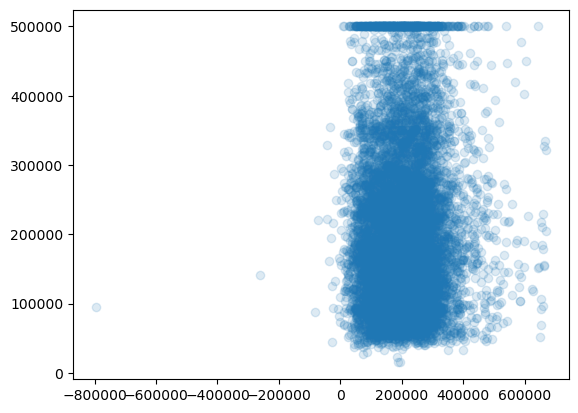

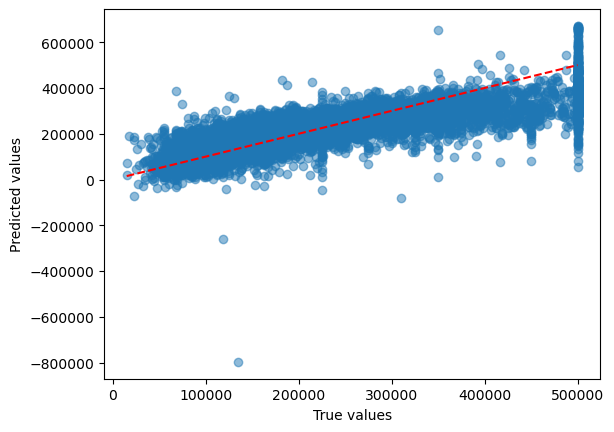

In [87]:
plt.scatter(y_pred, y_train,  alpha=0.15)
plt.show()

# We shouldn't do that, this plot don;t mean anything

# I plottet y_test because it makes more sense, since y_pred is traing to get y_test
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.show()



4. From the sklearn metrics module, print the mean_squared_error and R^2-score. What does the metrics tell us?

In [76]:
from sklearn import metrics

In [89]:
metrics.mean_squared_error(y_train, y_pred)

21455371032.77485

In [ ]:
# It measures the average square difference between predicted values and actual values, so the lesser the better. But our is very big.

#### Final Predictions

1. Now you are ready to make prediction on the test data. Do that and visualize your results in a new scatterplot.

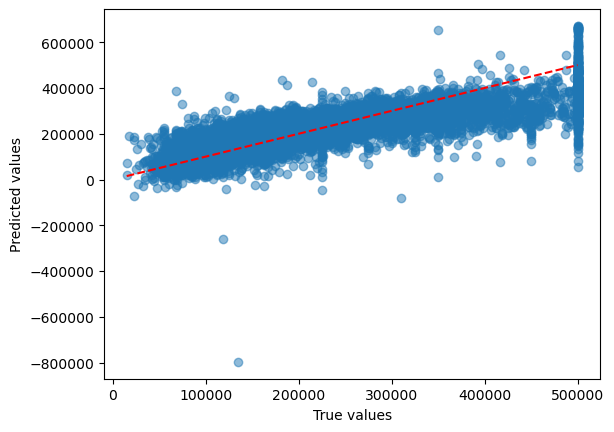

In [88]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.show()

2. Print the mean_squared_error and R^2-score again. What has happened?

In [91]:
metrics.mean_squared_error(y_test, y_pred)
# It's lesser than with the train, because it is what we are actually trying to get

4696227076.439252

3. There is another metric called Root mean squared error, Which is the square root of the MSE. Calculate the RMSE.

In [93]:
print(metrics.root_mean_squared_error(y_train, y_pred))
print(metrics.root_mean_squared_error(y_test, y_pred))

146476.52041462087
68529.0236063469


# Bonus Questions 1

1. Create a dataframe with two columns, one consisting of the y_test and one of your model's predictions.

In [111]:
print(len(y_pred))
print(len(y_test))

10318
10318


In [116]:
df_y_test = pd.DataFrame(y_test.reset_index(drop=True))
df_y_test.head()

,median_house_value
0,500001.0
1,161000.0
2,240900.0
3,88700.0
4,75800.0


In [113]:
df_y_pred = pd.DataFrame({'median_house_value_pred':y_pred})
df_y_pred.head()

,median_house_value_pred
0,366044.396163
1,240369.613155
2,243828.127395
3,150195.447124
4,89530.314563


In [118]:
df_con = pd.merge( df_y_test
                   ,df_y_pred
                   ,left_index=True
                   ,right_index=True
                   ,how='outer'
                 )
df_con

,median_house_value,median_house_value_pred
0,500001.0,366044.396163
1,161000.0,240369.613155
2,240900.0,243828.127395
3,88700.0,150195.447124
4,75800.0,89530.314563
...,...,...
10313,86300.0,212157.973875
10314,127300.0,146551.073654
10315,177200.0,144432.762287
10316,285800.0,253001.755895


2. Make a series of of your new dataframe, by calculating the predicted error in absolut numbers. Save this series to variable name `absolute_errors`.

In [123]:
df_con['absolute_errors'] = (df_con['median_house_value'] - df_con['median_house_value_pred']).abs()
df_con

,median_house_value,median_house_value_pred,absolute_errors
0,500001.0,366044.396163,133956.603837
1,161000.0,240369.613155,79369.613155
2,240900.0,243828.127395,2928.127395
3,88700.0,150195.447124,61495.447124
4,75800.0,89530.314563,13730.314563
...,...,...,...
10313,86300.0,212157.973875,125857.973875
10314,127300.0,146551.073654,19251.073654
10315,177200.0,144432.762287,32767.237713
10316,285800.0,253001.755895,32798.244105


3. If you take the mean of your series, you will get the mean absolute errors, which is another metric for Linear Regressions.

In [124]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,y_pred)
print(df_con['absolute_errors'].mean())
print(mae)

49777.35922044056
49777.35922044056


# Bonus Question 2 - Build a Random Forest Regressor

1. Build, fit and train a `RandomForestRegressor` model. Do this by following the same staps that you followed when building your `LinearRegression`.

In [126]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [129]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

rgsr_rf = RandomForestRegressor(n_estimators=200, max_depth=5)
rgsr_rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=5, n_estimators=200)

2. Make prediction on the test data and evaluate you results.

In [130]:
y_pred = rgsr.predict(X_test)

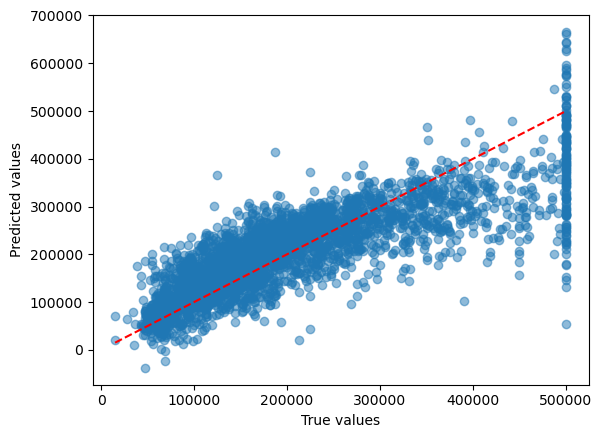

In [131]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.show()

In [133]:
from sklearn.metrics import r2_score

print("Mean absolute error: %.2f" % np.mean(np.absolute(y_pred - y_test)))
print("Residual sum of squares (MSE): %.2f" % np.mean((y_pred - y_test) ** 2))
print("R2-score: %.2f" % r2_score(y_test , y_pred) )

Mean absolute error: 49275.31
Residual sum of squares (MSE): 4588251290.09
R2-score: 0.65
